# 📊 Case Study (Indian Ecommerce)

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("final_enhanced_dataset_1.csv")
mobile_data = pd.read_excel("india_top_categories_1.xlsx")
trend_data = pd.read_csv("monthly_trend_analysis_1.csv")
delivery_data=pd.read_csv("product _delivery_data_ML.csv")
rbi_df =pd.read_csv("rbi_payment_metrics.csv")
df.head()

,Category_x,Product,Price,Seasonal_Sale,Trends_Category,date,Trend,Keyword,Category_y,Year,Month,Month_Name,Quarter,Type,Price_Numeric,Price_Segment,Date
0,Mobiles,Samsung Galaxy S25 Ultra,"Rs.108,990","Amazon Great Indian Festival (Oct), Flipkart B...",Smartphones,18-08-2024,64,Smartphones,Smartphones,2024,8,August,3,Sub Category,108990,Luxury (>60k),18-08-2024
1,Mobiles,Samsung Galaxy S25 Ultra,"Rs.108,990","Amazon Great Indian Festival (Oct), Flipkart B...",Smartphones,25-08-2024,67,Smartphones,Smartphones,2024,8,August,3,Sub Category,108990,Luxury (>60k),25-08-2024
2,Mobiles,Samsung Galaxy S25 Ultra,"Rs.108,990","Amazon Great Indian Festival (Oct), Flipkart B...",Smartphones,01-09-2024,69,Smartphones,Smartphones,2024,9,September,3,Sub Category,108990,Luxury (>60k),01-09-2024
3,Mobiles,Samsung Galaxy S25 Ultra,"Rs.108,990","Amazon Great Indian Festival (Oct), Flipkart B...",Smartphones,08-09-2024,78,Smartphones,Smartphones,2024,9,September,3,Sub Category,108990,Luxury (>60k),08-09-2024
4,Mobiles,Samsung Galaxy S25 Ultra,"Rs.108,990","Amazon Great Indian Festival (Oct), Flipkart B...",Smartphones,15-09-2024,84,Smartphones,Smartphones,2024,9,September,3,Sub Category,108990,Luxury (>60k),15-09-2024


In [4]:
mobile_data.head()

,Category,Product,Price
0,Mobiles,Samsung Galaxy S25 Ultra,"Rs.108,990"
1,Mobiles,Samsung Galaxy Z Fold7,"Rs.174,999"
2,Mobiles,Xiaomi 15 Ultra,"Rs.109,999"
3,Mobiles,vivo X200 Pro,"Rs.87,990"
4,Mobiles,OPPO Find X8 Pro,"Rs.92,999"


In [5]:
trend_data.head()

,Keyword,Year,Month,Trend
0,Apparel,2024,8,89.00
1,Apparel,2024,9,90.20
2,Apparel,2024,10,82.50
3,Apparel,2024,11,89.25
4,Apparel,2024,12,87.80


In [6]:
delivery_data.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitan,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitan,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitan,150,Toys


# 📊 Case Study: Payment Failures & Delivery Insights

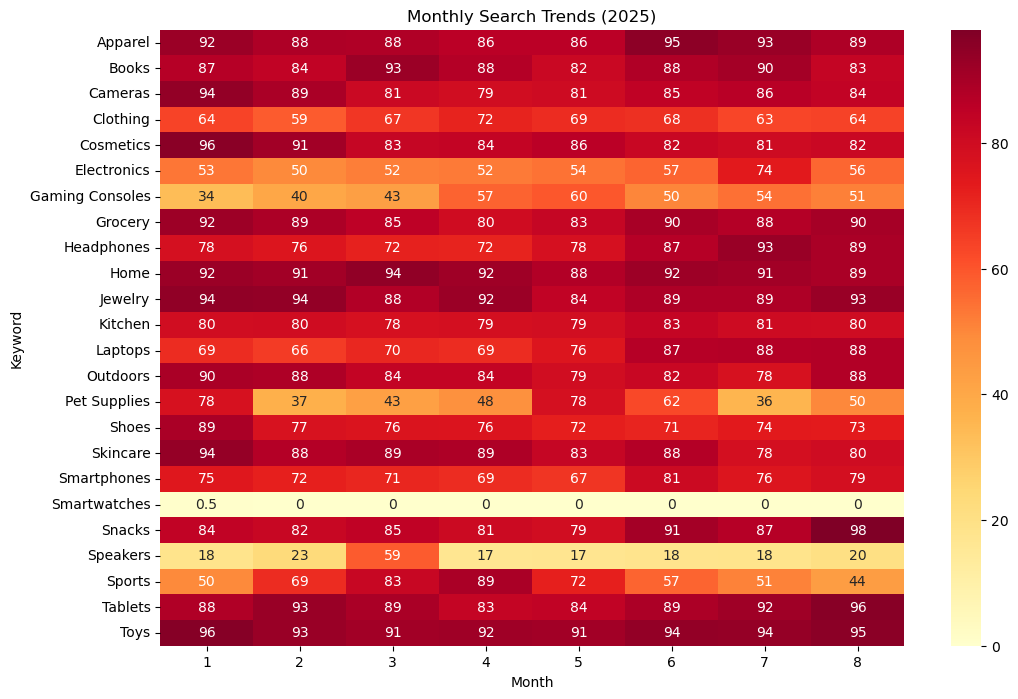

Top 5 Categories by Average Search Interest:
Keyword
Toys       93.235417
Home       91.160417
Jewelry    90.450000
Apparel    89.639583
Tablets    89.372917
Name: Trend, dtype: float64

Top 5 Categories with Highest Seasonal Variation:
Keyword
Pet Supplies       16.924153
Sports             16.483753
Speakers           14.255461
Laptops             9.387436
Gaming Consoles     8.986158
Name: Trend, dtype: float64


In [78]:
trend_2025 = trend_data[trend_data['Year'] == 2025]

# Heatmap
pivot = trend_2025.pivot(index='Keyword', columns='Month', values='Trend')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='YlOrRd')
plt.title('Monthly Search Trends (2025)')
plt.show()

# Top 5 categories by average interest
print("Top 5 Categories by Average Search Interest:")
print(trend_2025.groupby('Keyword')['Trend'].mean().nlargest(5))

# Top 5 categories by seasonal variation
print("\nTop 5 Categories with Highest Seasonal Variation:")
print(trend_2025.groupby('Keyword')['Trend'].std().nlargest(5))


In [9]:
# Conclusion:
# The data highlights two types of opportunities:
# Steady-demand categories (Apparel, Home, Grocery, Laptops) → ideal for long-term growth and consistent campaigns.
# Seasonal-demand categories (Toys, Pet Supplies, Sports, Speakers) → best leveraged with targeted promotions during peak months to maximize sales impact.

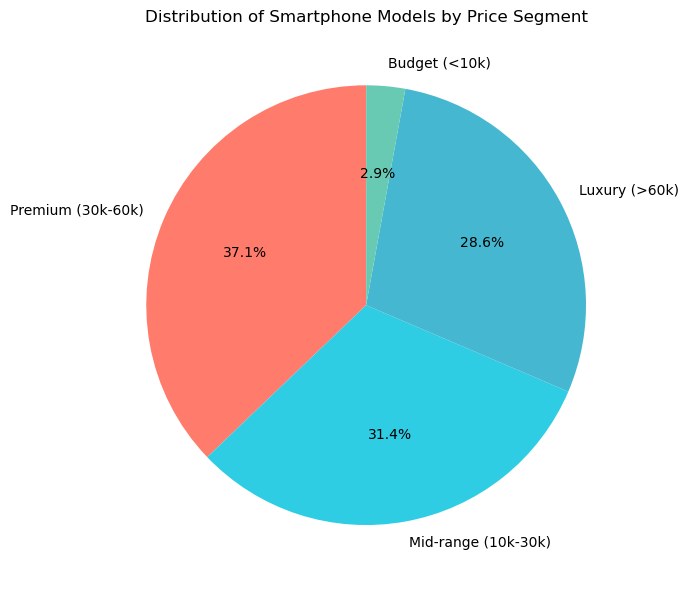

In [17]:
# Count unique products per price segment
segment_distribution = df.groupby('Price_Segment')['Product'].nunique().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
colors = ['#FF7B6B', '#2ECDE4', '#45B7D1', '#69CAB4',]
segment_distribution.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Smartphone Models by Price Segment')
plt.ylabel('')  # Hide the y-label
plt.tight_layout()
plt.savefig("piechart.png", dpi=300, bbox_inches="tight")
plt.show()

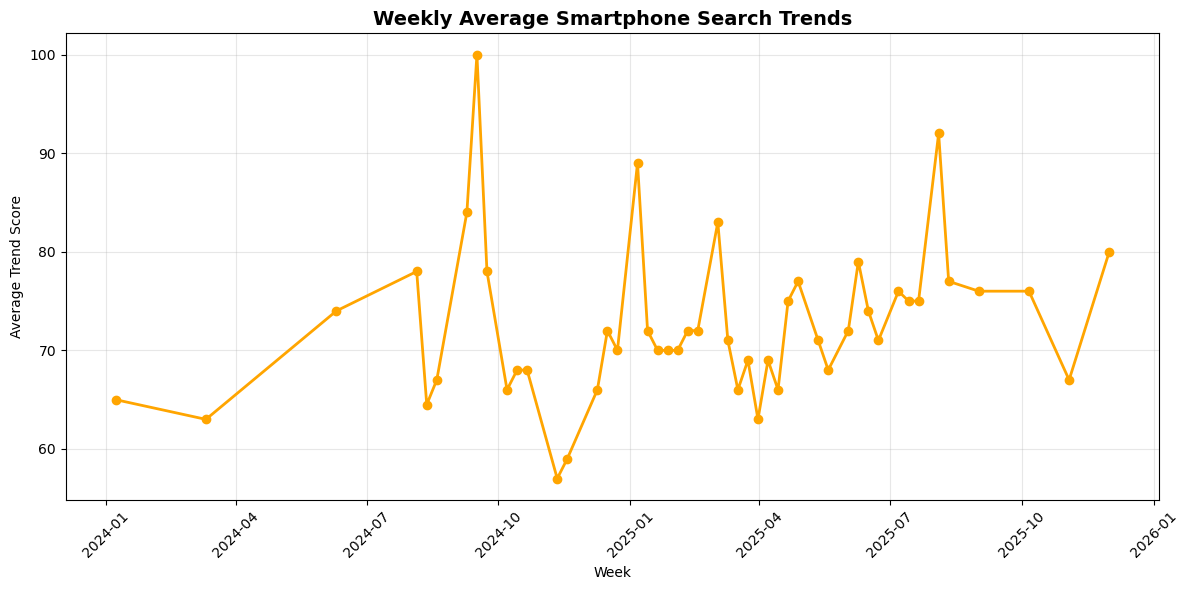

In [18]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Create weekly grouping
df['Week'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)

# Weekly average trends
weekly_trends = df.groupby('Week')['Trend'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(weekly_trends['Week'], weekly_trends['Trend'], marker='o', linewidth=2 , color ="orange" )
plt.title("Weekly Average Smartphone Search Trends", fontsize=14, fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Average Trend Score")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("linechart.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
#Note
# List all available colormaps
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', 'BuGn_r', 'BuPu_r', 'CMRmap_r', 'GnBu_r', 'G

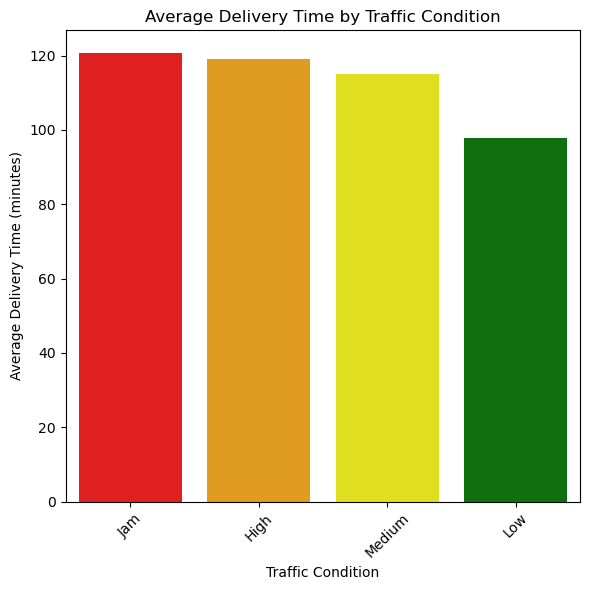

Average Delivery Time by Traffic:
Traffic
Jam       120.77
High      119.21
Medium    115.12
Low        97.89
Name: Delivery_Time, dtype: float64


In [36]:
# Calculate average delivery time for each traffic condition
traffic_delivery = df.groupby('Traffic')['Delivery_Time'].mean().sort_values(ascending=False)

# Define a custom palette for traffic conditions
traffic_palette = {
    "Jam": "red",       #  Critical
    "High": "orange",   #  Heavy
    "Medium": "yellow", #  Moderate
    "Low": "green"      #  Smooth
}

# Plotting
plt.figure(figsize=(6, 6))
sns.barplot(x=traffic_delivery.index, 
            y=traffic_delivery.values, 
            palette=traffic_palette)   # <-- custom palette here
plt.title('Average Delivery Time by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("barchart.png", dpi=200, bbox_inches="tight")
plt.show()

# Print the exact averages
print("Average Delivery Time by Traffic:")
print(traffic_delivery.round(2))

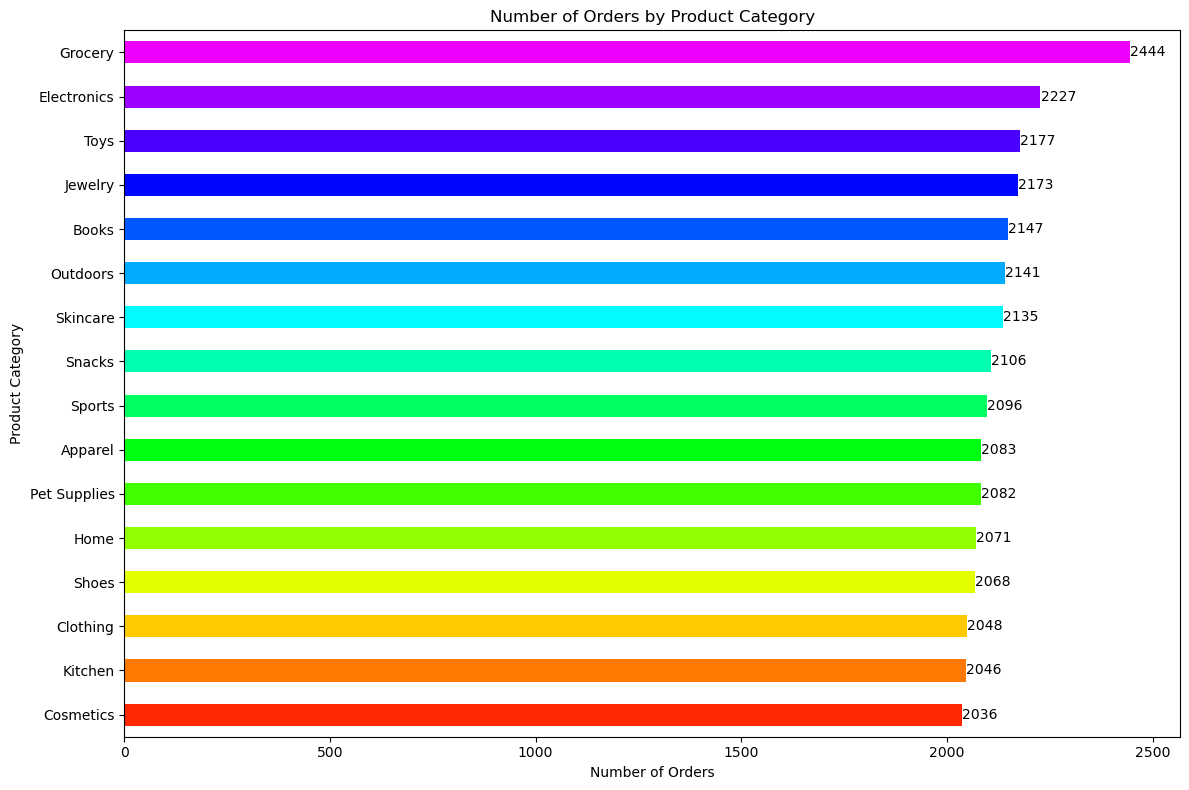

Order Count by Category:
Grocery         2444
Electronics     2227
Toys            2177
Jewelry         2173
Books           2147
Outdoors        2141
Skincare        2135
Snacks          2106
Sports          2096
Apparel         2083
Pet Supplies    2082
Home            2071
Shoes           2068
Clothing        2048
Kitchen         2046
Cosmetics       2036
Name: Category, dtype: int64


In [42]:
# Count categories
category_counts = df['Category'].value_counts()

# Colors
colors = sns.color_palette("gist_rainbow_r", len(category_counts))

# Plotting
plt.figure(figsize=(12, 8))
ax = category_counts.plot(kind='barh', color=colors)  # Horizontal bar chart

plt.title('Number of Orders by Product Category')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()  # Most orders at the top
plt.tight_layout()

# Annotate bars with values
for i, v in enumerate(category_counts.values):
    plt.text(v + 0.5, i, str(v), va='center')  
    # v + 0.5 shifts text slightly to the right of the bar

plt.savefig("barhchart.png", dpi=300, bbox_inches="tight")
plt.show()

print("Order Count by Category:")
print(category_counts)

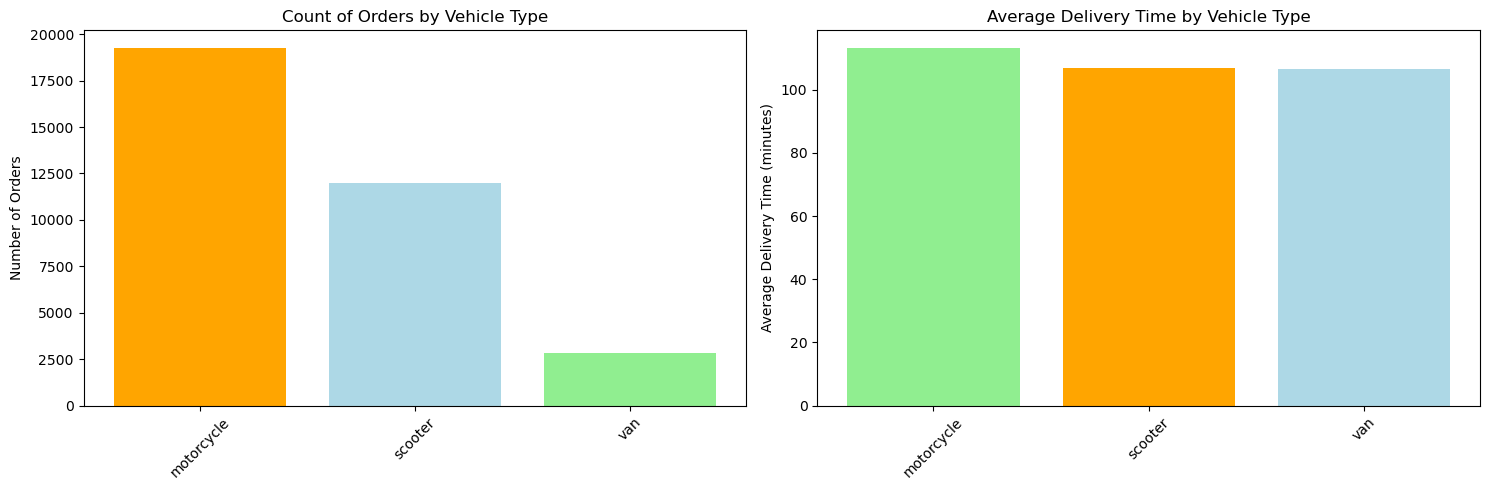

Order Count by Vehicle:
motorcycle    19242
scooter       11983
van            2855
Name: Vehicle, dtype: int64

Average Delivery Time by Vehicle:
Vehicle
motorcycle    113.16
scooter       106.77
van           106.43
Name: Delivery_Time, dtype: float64


In [44]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Count of orders by vehicle type
vehicle_count = df['Vehicle'].value_counts()
ax1.bar(vehicle_count.index, vehicle_count.values, color=['orange', 'lightblue', 'lightgreen'])
ax1.set_title('Count of Orders by Vehicle Type')
ax1.set_ylabel('Number of Orders')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average delivery time by vehicle type
vehicle_delivery = df.groupby('Vehicle')['Delivery_Time'].mean().sort_values(ascending=False)
ax2.bar(vehicle_delivery.index, vehicle_delivery.values, color=['lightgreen', 'orange', 'lightblue'])
ax2.set_title('Average Delivery Time by Vehicle Type')
ax2.set_ylabel('Average Delivery Time (minutes)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Order Count by Vehicle:")
print(vehicle_count)
print("\nAverage Delivery Time by Vehicle:")
print(vehicle_delivery.round(2))

In [53]:
# Conclusion:
# Motorcycles dominate deliveries due to their balance of speed and capacity, but scooters are the most time-efficient option for urban routes. 
# Vans, while slower, are essential for bulk or long-distance deliveries. 
# Businesses should optimize fleet allocation by using scooters for high-density urban areas, 
# motorcycles for general deliveries, and vans for large-volume or specialized orders.

In [57]:
print(rbi_df.columns)

Index(['date,upi_failure_rate,card_failure_rate,netbanking_failure_rate,total_transactions', 'total_transactions'], dtype='object')


In [59]:
df = pd.read_csv("product _delivery_data_ML.csv", delimiter=",")

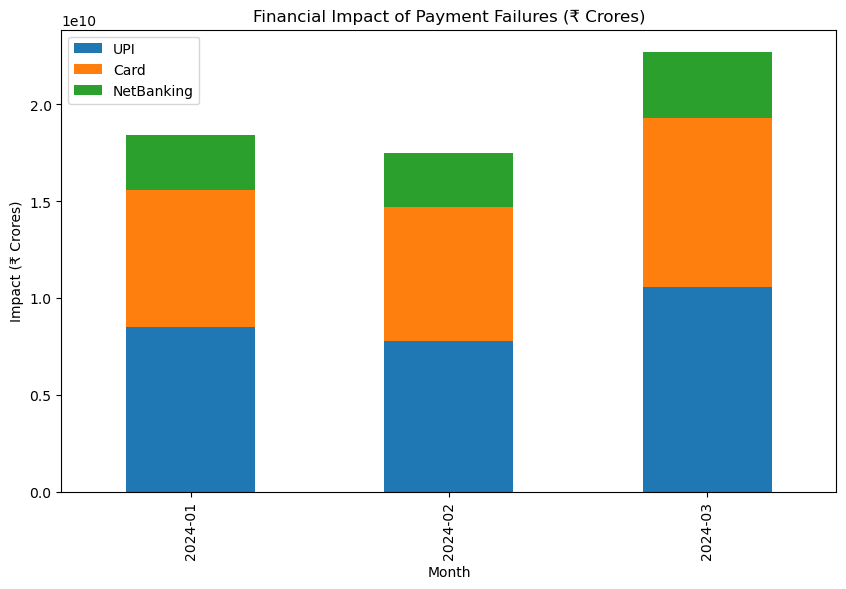

In [77]:
financial_data = rbi_df[['date','upi_financial_impact','card_financial_impact','netbanking_financial_impact']].set_index('date')
financial_data.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Financial Impact of Payment Failures (₹ Crores)")
plt.ylabel("Impact (₹ Crores)")
plt.xlabel("Month")
plt.legend(["UPI","Card","NetBanking"])
plt.show()

In [63]:
#Conclusion:
#Payment failures pose a significant financial and customer experience risk, costing over ₹6,400 crores in a single quarter. While Net Banking has the highest failure rates, 
#UPI failures drive the largest revenue loss because of its dominance in transaction volume. Targeted efforts to reduce UPI and Card failures can deliver the biggest financial and customer satisfaction gains.

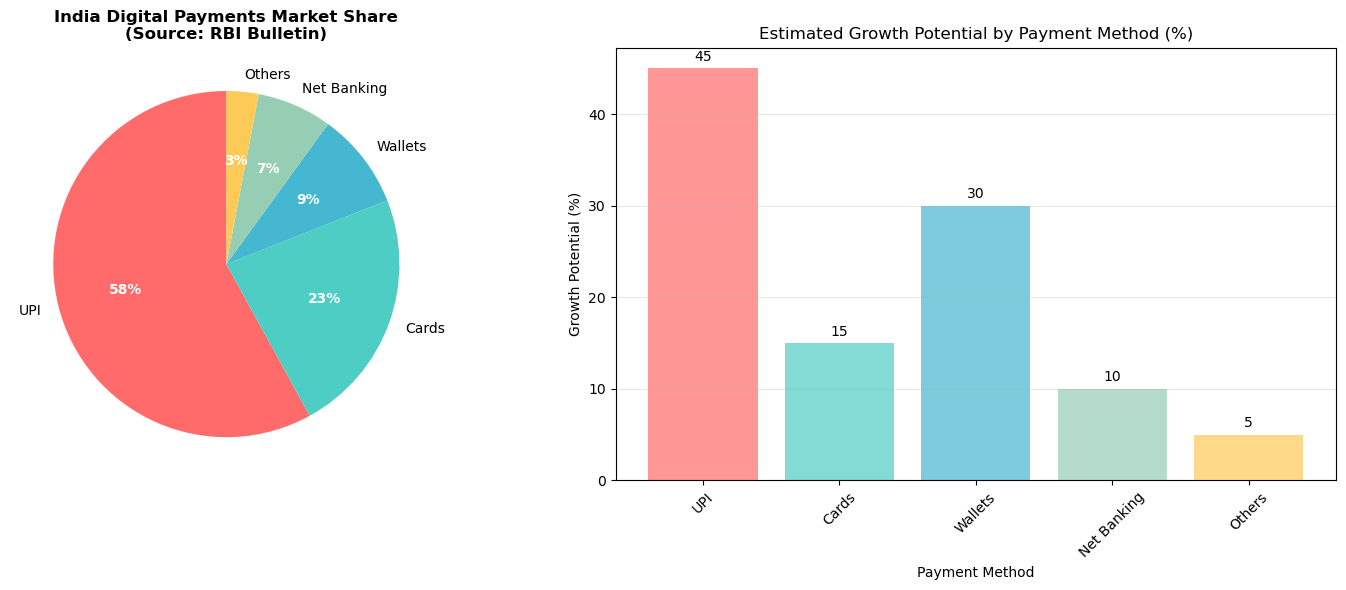

Digital Payments Landscape Analysis Summary:
  Payment Method  Current Market Share (%)  Growth Potential (%) FDI Friendly                            Key Opportunities
0            UPI                        58                    45          Yes  Low cost, high adoption, government support
1          Cards                        23                    15          Yes    High value transactions, loyalty programs
2        Wallets                         9                    30      Limited        Closed ecosystems, specific use cases
3    Net Banking                         7                    10          Yes   Corporate transactions, older demographics
4         Others                         3                     5       Varies      Niche applications, specialized markets


In [70]:
# Data from RBI on Digital Payments Market Share
payment_methods = ['UPI', 'Cards', 'Wallets', 'Net Banking', 'Others']
market_share = [58, 23, 9, 7, 3]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for payment method market share
wedges, texts, autotexts = ax1.pie(market_share, labels=payment_methods, autopct='%1.0f%%', 
                                   colors=colors, startangle=90)
ax1.set_title('India Digital Payments Market Share\n(Source: RBI Bulletin)', fontweight='bold')

# Make the labels more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Bar chart showing growth potential
growth_potential = [45, 15, 30, 10, 5]  # Estimated growth potential for each segment
x_pos = np.arange(len(payment_methods))

ax2.bar(x_pos, growth_potential, color=colors, alpha=0.7)
ax2.set_title('Estimated Growth Potential by Payment Method (%)')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Growth Potential (%)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(payment_methods, rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(growth_potential):
    ax2.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('digital_payments_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a summary table
data = {
    'Payment Method': payment_methods,
    'Current Market Share (%)': market_share,
    'Growth Potential (%)': growth_potential,
    'FDI Friendly': ['Yes', 'Yes', 'Limited', 'Yes', 'Varies'],
    'Key Opportunities': [
        'Low cost, high adoption, government support',
        'High value transactions, loyalty programs',
        'Closed ecosystems, specific use cases',
        'Corporate transactions, older demographics',
        'Niche applications, specialized markets'
    ]
}

summary_df = pd.DataFrame(data)
print("Digital Payments Landscape Analysis Summary:")
print("=" * 70)
print(summary_df.to_string(index =True))

# Payment Failures & Delivery Insights

Q1. Which payment method had the highest average failure rate between Jan–Mar 2024?


In [72]:
print("Average Failure Rates (Jan-Mar 2024):")
print("UPI:", round(rbi_df['upi_failure_rate'].mean(), 2), "%")
print("Card:", round(rbi_df['card_failure_rate'].mean(), 2), "%")
print("NetBanking:", round(rbi_df['netbanking_failure_rate'].mean(), 2), "%")

Average Failure Rates (Jan-Mar 2024):
UPI: 2.07 %
Card: 3.5 %
NetBanking: 4.2 %


Q2. What was the total financial impact of UPI failures across all months?


In [73]:
upi_total_impact = rbi_df['upi_financial_impact'].sum() / 10000000
print(f"Total UPI Financial Impact: ₹{upi_total_impact:.2f} crores")

Total UPI Financial Impact: ₹2683.80 crores


Q3. If UPI failure rate dropped by 1% each month, how much money would be saved?


In [74]:
#Approach:
#Recalculate failed transactions with (upi_failure_rate - 1).
#Compare with original impact.


reduced_upi_failures = rbi_df['total_transactions'] * 0.6 * ((rbi_df['upi_failure_rate'] - 1) / 100)
saved_money = (rbi_df['upi_failed_transactions'] - reduced_upi_failures) * avg_transaction_value
print(f"Money Saved if UPI failure drops by 1% each month: ₹{saved_money.sum()/10000000:.2f} crores")

Money Saved if UPI failure drops by 1% each month: ₹1296.00 crores


In [80]:
traffic_delivery = delivery_data.groupby('Traffic')['Delivery_Time'].mean()
worst_traffic = traffic_delivery.idxmax()
print(f"Worst traffic condition: {worst_traffic} ({traffic_delivery.max():.2f} minutes)")

Worst traffic condition: Jam (120.77 minutes)


✨ Final Insights 

The analysis reveals a story of both opportunity and challenge. Payment systems, while driving massive transaction volumes, continue to face reliability gaps that translate into significant financial impact. UPI, despite being the most widely adopted, shows resilience with relatively lower failure rates, yet even small inefficiencies at scale create losses worth crores. Card transactions remain steady but highlight the need for infrastructure upgrades, while NetBanking consistently emerges as the weakest link, raising questions about its long‑term viability in a digital‑first economy.

On the delivery side, operational efficiency is deeply tied to external conditions. Vehicle choice and traffic patterns directly shape customer experience, with bikes excelling in speed but struggling under congestion, and heavier vehicles offering stability at the cost of delays. Categories with high seasonal demand spikes show how consumer behavior is dynamic, influenced by festivals, promotions, and broader lifestyle shifts. This volatility is both a risk and an opportunity — businesses that anticipate and adapt to these cycles can capture outsized gains.

Taken together, the findings suggest that reliability and adaptability are the twin pillars of growth. Reducing failure rates by even a single percentage point could save crores, while optimizing delivery logistics around traffic and demand cycles could transform customer satisfaction. The broader opinion that emerges is clear: India’s digital commerce ecosystem is robust and expanding, but its next leap forward depends on tightening the weak links in payments and logistics. Those who invest in resilience today will define the winners of tomorrow.

